# Projet HISTA

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.datasets import load_diabetes, load_breast_cancer, load_wine
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
import os


SEED = 42

np.random.seed(SEED)  # Pour avoir toujours les mêmes résultats

## Question 1

On reprend les paramètres de l'énoncé et on travaille sur des données standardisées.

In [2]:
# On recopie les paramètres de l'énoncé et on génère les différents paramètres
n = 20
p = 8
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])

X = np.random.multivariate_normal(np.zeros(p), np.eye(p), size=n)
epsilon = np.random.normal(0, 1, size=n)
y = X @ beta_star + epsilon

# Nous devons bien standardiser les données comme le dit Tibishirani
# #afin que la pénialité L1 soit équitable entre les coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Affichage pour vérification
print("Dimensions de X_scaled :", X_scaled.shape)
print("Vecteur beta* :", beta_star)

Dimensions de X_scaled : (20, 8)
Vecteur beta* : [5.  3.  0.  0.  1.5 0.  0.  0. ]


## Question 2

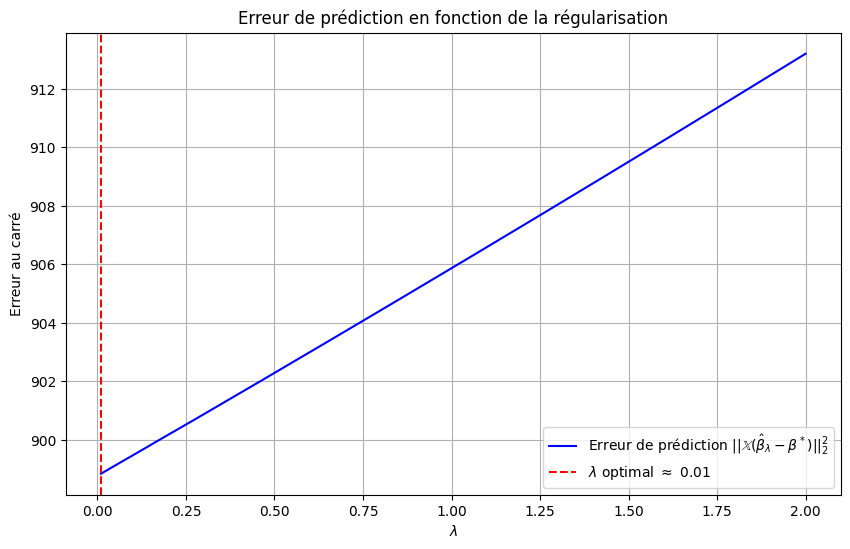

Le lambda optimal (in-sample) est : 0.01


In [3]:
# On définit l'espace pour la fonction comme suggéré dans le rapport
lambdas = np.arange(0.01, 2.01, 0.01)
errors = []
coeffs = []

for l in lambdas:
    # Correspondance avec sklearn : alpha = lambda / (2 * n)
    # pour coller à la formulation RSS + lambda * ||beta||1
    model = Lasso(alpha=l/(2*n), fit_intercept=False, random_state=SEED)
    model.fit(X_scaled, y)

    # Calcul de l'erreur
    y_pred_pure = X_scaled @ model.coef_
    y_true_pure = X_scaled @ (beta_star / scaler.scale_) # On ajuste à l'échelle

    error = np.sum((y_pred_pure - y_true_pure)**2)
    errors.append(error)
    coeffs.append(model.coef_)

# On cherche alors le lambda optimal
idx_opt = np.argmin(errors)
lambda_opt = lambdas[idx_opt]
min_error = errors[idx_opt]

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(lambdas, errors, label='Erreur de prédiction $||\\mathbb{X}(\\hat{\\beta}_\\lambda - \\beta^*)||_2^2$', color='blue')
plt.axvline(x=lambda_opt, color='red', linestyle='--', label=f'$\\lambda$ optimal $\\approx$ {lambda_opt:.2f}')
plt.xlabel('$\\lambda$')
plt.ylabel('Erreur au carré')
plt.title('Erreur de prédiction en fonction de la régularisation')
plt.legend()
plt.grid(True)
plt.show()

print(f"Le lambda optimal (in-sample) est : {lambda_opt:.2f}")

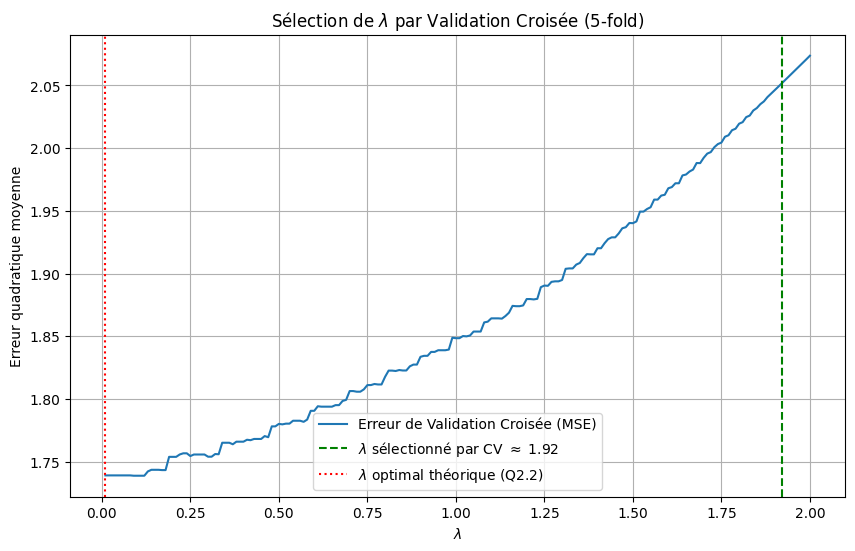

Le lambda sélectionné par CV est : 1.92


In [4]:
# 1. Configuration de la Validation Croisée avec 5 folds comme dans l'article
model_cv = LassoCV(
    alphas=lambdas/(2*n), # Conversion au format sklearn
    cv=5,
    fit_intercept=False,
    max_iter=10000,
    random_state=SEED
)

# Entraînement
model_cv.fit(X_scaled, y)

# Extraction des résultats
lambda_cv = model_cv.alpha_ * (2 * n)
mse_path = model_cv.mse_path_.mean(axis=1) # Moyenne des erreurs sur les 5 folds

# Graphique de comparaison
plt.figure(figsize=(10, 6))
plt.plot(lambdas, mse_path, label='Erreur de Validation Croisée (MSE)')
plt.axvline(x=lambda_cv, color='green', linestyle='--', label=f'$\\lambda$ sélectionné par CV $\\approx$ {lambda_cv:.2f}')
plt.axvline(x=0.01, color='red', linestyle=':', label='$\\lambda$ optimal théorique (Q2.2)')
plt.xlabel('$\\lambda$')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Sélection de $\\lambda$ par Validation Croisée (5-fold)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Le lambda sélectionné par CV est : {lambda_cv:.2f}")

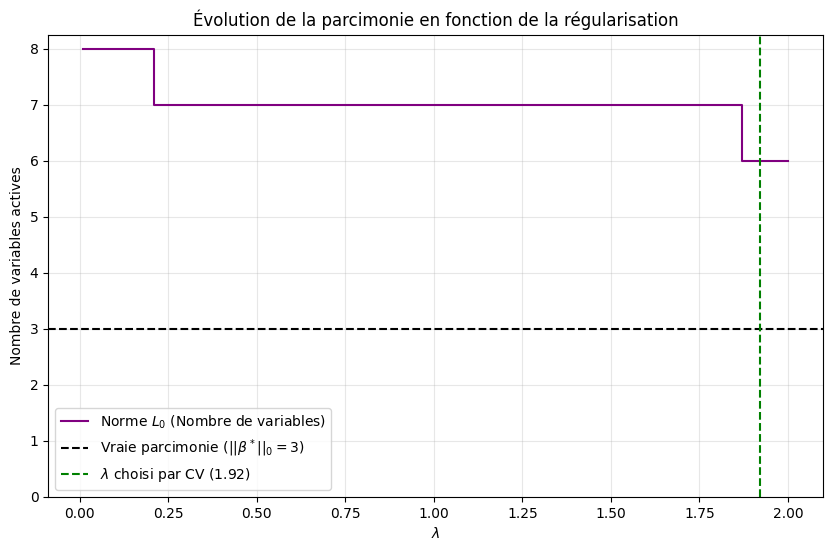

Nombre de variables sélectionnées pour lambda_cv : 6
Indices des variables sélectionnées : [0 1 2 3 4 6]


In [5]:
# Calcul de la norme L0 pour chaque lambda
# On utilise les coefficients déjà calculés à la question 2.2
l0_norms = [np.sum(np.abs(c) > 1e-5) for c in coeffs]

# Visualisation
plt.figure(figsize=(10, 6))
plt.step(lambdas, l0_norms, where='post', color='purple', label='Norme $L_0$ (Nombre de variables)')
plt.axhline(y=3, color='black', linestyle='--', label='Vraie parcimonie ($||\\beta^*||_0 = 3$)')
plt.axvline(x=lambda_cv, color='green', linestyle='--', label=f'$\\lambda$ choisi par CV ({lambda_cv:.2f})')

plt.xlabel('$\\lambda$')
plt.ylabel('Nombre de variables actives')
plt.title('Évolution de la parcimonie en fonction de la régularisation')
plt.yticks(range(0, 9))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Affichage des variables sélectionnées au lambda_cv
best_model_idx = np.abs(lambdas - lambda_cv).argmin()
selected_vars = np.where(np.abs(coeffs[best_model_idx]) > 1e-5)[0]
print(f"Nombre de variables sélectionnées pour lambda_cv : {l0_norms[best_model_idx]}")
print(f"Indices des variables sélectionnées : {selected_vars}")

## Question 3

On travaille ici sur des données réelles de classification (cancer du sein). La cible est binaire, ce qui justifie l'utilisation d'une régression logistique avec pénalité Lasso.

In [6]:
# Chargement des données depuis le dépôt UCI
# Documentation : https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

from ucimlrepo import fetch_ucirepo

breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis']

features = X.columns

print(breast_cancer_wisconsin_diagnostic.metadata)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [7]:
# Aperçu des données
print(X.head(5))
print(y.head(5))


   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

La cible est binaire (M = malin, B = bénin), ce qui justifie l'utilisation d'une régression logistique. Cela correspond exactement à la section 8.1 de l'article, qui étend le Lasso au cadre de la vraisemblance maximale pénalisée.

In [8]:
# Prétraitement des données
y_encoded = np.where(y == 'M', 1, 0)  # Encodage binaire de la cible (M=1, B=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:

# sklearn utilise C = 1/lambda, contrairement à la convention de l'exercice 1
Cs = 1 / lambdas

coefs = []
for c in Cs:
    # Le solver liblinear est requis pour la pénalité L1
    clf = LogisticRegression(l1_ratio=1, C=c, solver='liblinear', random_state=SEED)
    clf.fit(X_scaled, y_encoded)
    coefs.append(clf.coef_[0])

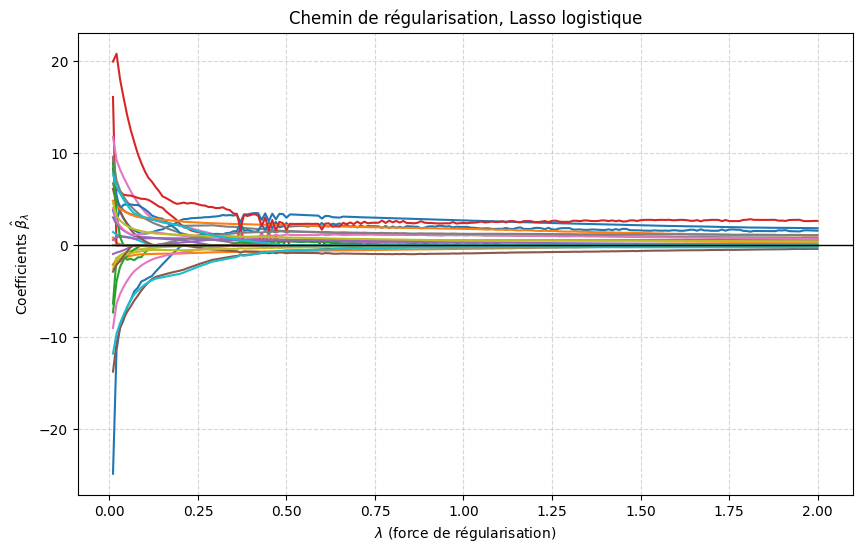

In [10]:
coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
for i in range(coefs.shape[1]):
    plt.plot(lambdas, coefs[:, i])

plt.xlabel(r'$\lambda$ (force de régularisation)')
plt.ylabel(r'Coefficients $\hat{\beta}_\lambda$')
plt.title('Chemin de régularisation, Lasso logistique')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.show()


In [11]:
from sklearn.linear_model import LogisticRegressionCV
import numpy as np


Cs_fast = np.logspace(-3, 1, 10)

clf_cv = LogisticRegressionCV(
    Cs=Cs_fast,
    cv=5,
    l1_ratios=(1,),
    solver='liblinear',
    max_iter=5000,
    tol=1e-3,
    random_state=SEED,
    use_legacy_attributes=True
)

clf_cv.fit(X_scaled, y_encoded)

best_C = clf_cv.C_[0]
best_lambda = 1 / best_C

print(f'Valeur optimale de C : {best_C:.4f}')
print(f'Lambda optimal : {best_lambda:.4f}\n')

# Coefficients au lambda optimal
optimal_coefs = clf_cv.coef_[0]


threshold = 1e-6
active_mask = np.abs(optimal_coefs) > threshold

active_vars = np.array(features)[active_mask]
active_weights = optimal_coefs[active_mask]

print(f'Variables actives ({len(active_vars)} sur {len(features)}) :')

# Tri par valeur absolue décroissante
sorted_indices = np.argsort(np.abs(active_weights))[::-1]

for idx in sorted_indices:
    print(f'{active_vars[idx]:<25}: {active_weights[idx]:.4f}')

Valeur optimale de C : 0.1668
Lambda optimal : 5.9948

Variables actives (11 sur 30) :
radius3                  : 1.1424
perimeter3               : 1.0038
area3                    : 0.9786
radius2                  : 0.8852
texture3                 : 0.8822
concave_points3          : 0.8305
concave_points1          : 0.5834
smoothness3              : 0.4252
symmetry3                : 0.2762
concavity3               : 0.0906
fractal_dimension2       : -0.0210


## Bonus : Lasso sur autres jeux de données

Un **chemin de régularisation** trace l'évolution des coefficients $\hat\beta_j(\lambda)$ lorsque $\lambda$ varie de petit (peu de régularisation) à grand (modèle nul). On illustre ici le chemin Lasso sur les trois jeux de données réels. Les coefficients dont la trajectoire est **non-monotone** (leur valeur absolue remonte à un moment donné lorsque $\lambda$ croît) sont tracés en rouge.

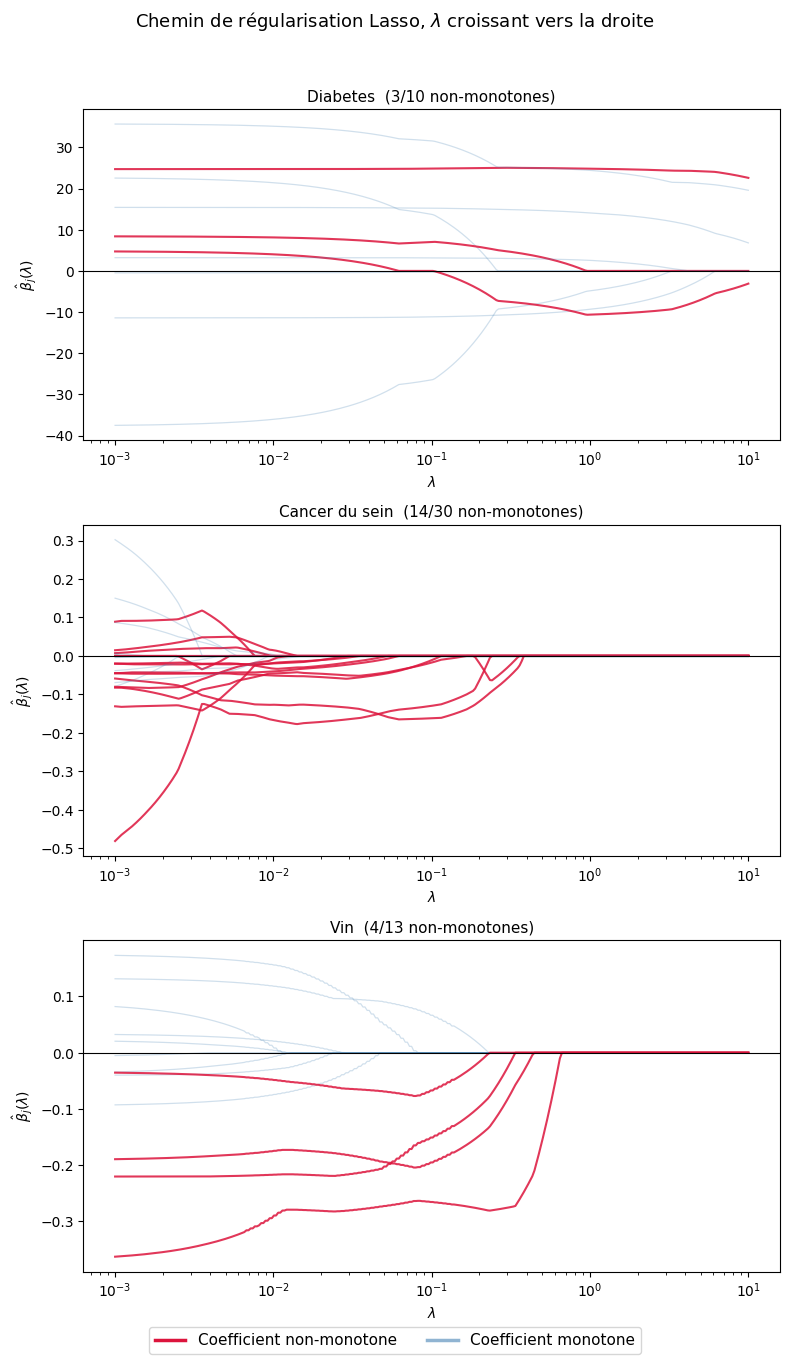

In [12]:
from sklearn.linear_model import lasso_path

alphas_path = np.logspace(1, -3, 300)

DATASETS_BONUS = [
    ('Diabetes', load_diabetes()),
    ('Cancer du sein', load_breast_cancer()),
    ('Vin', load_wine()),
]

def detect_non_monotone(coefs_desc, tol=1e-6):
    return np.any(np.diff(np.abs(coefs_desc), axis=1) < -tol, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(8, 13))
fig.suptitle(
    r'Chemin de régularisation Lasso, $\lambda$ croissant vers la droite',
    fontsize=13, y=1.02
)

for row, (ds_name, data) in enumerate(DATASETS_BONUS):
    X_d = StandardScaler().fit_transform(data.data)
    y_d = data.target.astype(float)
    y_d -= y_d.mean()
    p_d = X_d.shape[1]

    alphas_lasso, coefs_lasso, _ = lasso_path(X_d, y_d, alphas=alphas_path)
    mask_lasso = detect_non_monotone(coefs_lasso)
    lam_plot = alphas_lasso[::-1]
    coefs_plot = coefs_lasso[:, ::-1]
    n_nm = int(mask_lasso.sum())

    ax = axes[row]
    for j in range(p_d):
        color = 'crimson' if mask_lasso[j] else 'steelblue'
        alpha = 0.85 if mask_lasso[j] else 0.25
        lw    = 1.5  if mask_lasso[j] else 0.9
        ax.plot(lam_plot, coefs_plot[j], color=color, alpha=alpha, lw=lw)

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xscale('log')
    ax.set_title(f'{ds_name}  ({n_nm}/{p_d} non-monotones)', fontsize=11)
    ax.set_xlabel(r'$\lambda$', fontsize=10)
    ax.set_ylabel(r'$\hat\beta_j(\lambda)$', fontsize=10)

from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([0], [0], color='crimson', lw=2.5, label='Coefficient non-monotone'),
    Line2D([0], [0], color='steelblue', lw=2.5, alpha=0.6, label='Coefficient monotone'),
], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


## Bonus 2 : Stabilité des variables sélectionnées

Dans la question précédente, le Lasso logistique permettait de sélectionner un sous-ensemble de variables importantes. Cependant, une question naturelle est de savoir si cette sélection est stable. L'idée est la suivante : si une variable est réellement importante, elle devrait être sélectionnée souvent, même lorsque l'échantillon d'entraînement change légèrement. Au contraire, une variable sélectionnée seulement dans quelques répétitions est probablement moins robuste. On répète donc plusieurs fois l'entraînement d'une régression logistique pénalisée L1 sur des sous-échantillons bootstrap, puis on mesure la fréquence de sélection de chaque variable.

In [13]:
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression

n_bootstrap = 100
threshold = 1e-6

selected_matrix = np.zeros((n_bootstrap, X_scaled.shape[1]))

C_opt = clf_cv.C_[0]

for b in range(n_bootstrap):
    X_b, y_b = resample(
        X_scaled,
        y_encoded,
        replace=True,
        random_state=SEED + b
    )

    clf_b = LogisticRegression(
        C=C_opt,
        l1_ratio=1,
        solver='liblinear',
        max_iter=10000,
        random_state=SEED + b
    )

    clf_b.fit(X_b, y_b)

    selected_matrix[b, :] = np.abs(clf_b.coef_[0]) > threshold

selection_freq = selected_matrix.mean(axis=0)

stability_df = pd.DataFrame({
    "Variable": features,
    "Frequence_selection": selection_freq
}).sort_values("Frequence_selection", ascending=False)

stability_df.head(15)

,Variable,Frequence_selection
24,smoothness3,0.98
21,texture3,0.98
27,concave_points3,0.96
20,radius3,0.93
10,radius2,0.90
28,symmetry3,0.89
7,concave_points1,0.87
26,concavity3,0.64
23,area3,0.54
19,fractal_dimension2,0.43


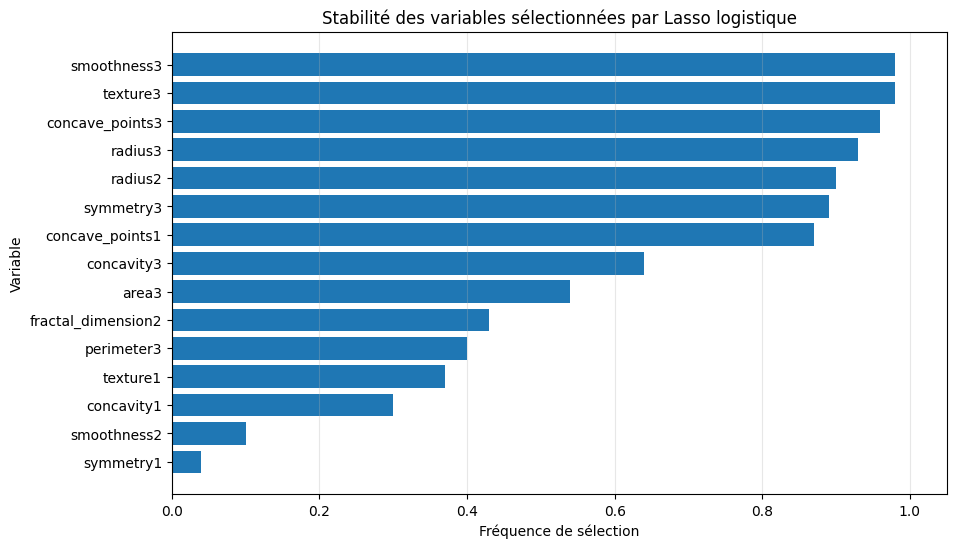

In [14]:
# Affichage des variables les plus stables
top_k = 15
top_variables = stability_df.head(top_k)

plt.figure(figsize=(10, 6))
plt.barh(
    top_variables['Variable'][::-1],
    top_variables['Frequence_selection'][::-1]
)

plt.xlabel('Fréquence de sélection')
plt.ylabel('Variable')
plt.title('Stabilité des variables sélectionnées par Lasso logistique')
plt.xlim(0, 1.05)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [15]:
# Variables très stables
stable_vars = stability_df[stability_df['Frequence_selection'] >= 0.8]

# Variables moyennement stables
medium_vars = stability_df[
    (stability_df['Frequence_selection'] >= 0.5) &
    (stability_df['Frequence_selection'] < 0.8)
]

# Variables instables
unstable_vars = stability_df[stability_df['Frequence_selection'] < 0.5]

print("Variables très stables :")
print(stable_vars[['Variable', 'Frequence_selection']])

print("\nVariables moyennement stables :")
print(medium_vars[['Variable', 'Frequence_selection']])

print("\nNombre de variables rarement sélectionnées :", len(unstable_vars))

Variables très stables :
           Variable  Frequence_selection
24      smoothness3                 0.98
21         texture3                 0.98
27  concave_points3                 0.96
20          radius3                 0.93
10          radius2                 0.90
28        symmetry3                 0.89
7   concave_points1                 0.87

Variables moyennement stables :
      Variable  Frequence_selection
26  concavity3                 0.64
23       area3                 0.54

Nombre de variables rarement sélectionnées : 21


On observe que certaines variables sont sélectionnées dans une grande majorité des échantillons bootstrap. Ces variables peuvent être considérées comme les plus robustes du point de vue du Lasso logistique. Cette analyse est importante car le Lasso ne fournit pas seulement un modèle prédictif : il est aussi utilisé comme méthode de sélection de variables. Or, si la sélection change fortement lorsque les données changent légèrement, il faut être prudent dans l'interprétation médicale des coefficients. Les variables avec une fréquence de sélection élevée sont donc plus fiables pour l'interprétation. Au contraire, les variables sélectionnées rarement ne doivent pas être considérées comme des facteurs déterminants.

## Bonus 3 : Comparaison entre Lasso, Ridge et Elastic Net

On compare maintenant trois méthodes de régularisation pour la régression logistique :

- **Ridge** : pénalisation L2. Elle réduit les coefficients, mais ne les met presque jamais exactement à zéro.
- **Lasso** : pénalisation L1. Elle peut annuler certains coefficients, donc elle réalise une sélection de variables.
- **Elastic Net** : combinaison des pénalisations L1 et L2. Elle peut sélectionner des variables comme le Lasso, tout en étant plus stable lorsque plusieurs variables sont corrélées.

L'objectif est de comparer leur performance prédictive et le nombre de variables sélectionnées.

In [16]:


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.25,
    random_state=SEED,
    stratify=y_encoded
)

models = {
    "Ridge (L2)": LogisticRegressionCV(
        Cs=Cs,
        cv=5,
        l1_ratios=(0,),
        solver="liblinear",
        max_iter=10000,
        random_state=SEED,
        use_legacy_attributes=True
    ),

    "Lasso (L1)": LogisticRegressionCV(
        Cs=Cs,
        cv=5,
        l1_ratios=(1,),
        solver="liblinear",
        max_iter=10000,
        random_state=SEED,
        use_legacy_attributes=True
    ),

    "Elastic Net": LogisticRegressionCV(
        Cs=Cs,
        cv=5,
        solver="saga",
        l1_ratios=[0.2, 0.5, 0.8],
        max_iter=10000,
        random_state=SEED,
        use_legacy_attributes=True
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    coef = model.coef_[0]
    n_selected = np.sum(np.abs(coef) > 1e-6)

    results.append({
        "Méthode": name,
        "Accuracy": acc,
        "AUC": auc,
        "Nombre de variables sélectionnées": n_selected,
        "C optimal": model.C_[0]
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Méthode,Accuracy,AUC,Nombre de variables sélectionnées,C optimal
0,Ridge (L2),0.965035,0.997065,30,0.680272
1,Lasso (L1),0.965035,0.996855,13,1.204819
2,Elastic Net,0.965035,0.997275,28,0.724638


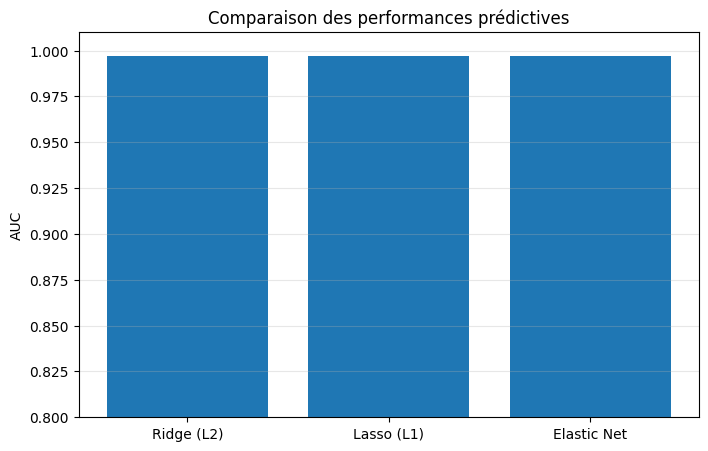

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Méthode"],
    comparison_df["AUC"]
)

plt.ylabel("AUC")
plt.title("Comparaison des performances prédictives")
plt.ylim(0.8, 1.01)
plt.grid(axis="y", alpha=0.3)
plt.show()

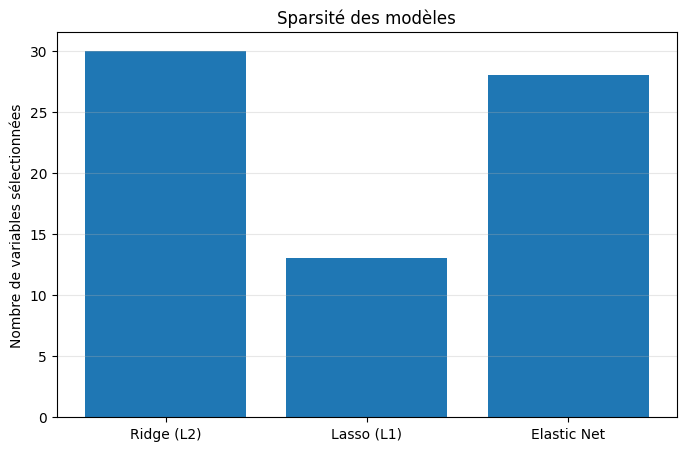

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Méthode"],
    comparison_df["Nombre de variables sélectionnées"]
)

plt.ylabel("Nombre de variables sélectionnées")
plt.title("Sparsité des modèles")
plt.grid(axis="y", alpha=0.3)
plt.show()

Les trois méthodes donnent généralement de bonnes performances prédictives sur le jeu de données du cancer du sein. Cependant, elles ne se comportent pas de la même manière du point de vue de l'interprétation.

La méthode Ridge garde toutes les variables dans le modèle, car la pénalisation L2 réduit les coefficients sans les annuler exactement. Elle est donc utile pour améliorer la stabilité du modèle, mais elle ne permet pas vraiment de sélectionner directement les variables les plus importantes.

Le Lasso, au contraire, produit un modèle plus parcimonieux. Plusieurs coefficients deviennent exactement nuls, ce qui facilite l'interprétation. Cette propriété est intéressante dans un contexte médical, car elle permet d'identifier un nombre réduit de variables potentiellement importantes.

Elastic Net représente un compromis entre Ridge et Lasso. Il conserve une partie de la capacité de sélection du Lasso, mais il est souvent plus stable lorsque certaines variables explicatives sont fortement corrélées. Cette situation est fréquente dans les données médicales, où plusieurs mesures peuvent décrire des propriétés similaires de la tumeur.

Ainsi, le choix de la méthode ne dépend pas seulement de la performance prédictive. Il dépend aussi de l'objectif de l'analyse : prédiction pure, interprétation, ou compromis entre stabilité et sélection de variables.

## Bonus 4 : Extension haute dimensionnelle — GSE96058 (SCAN-B, RNA-seq)

Le jeu de données **SCAN-B / GSE96058** (Brueffer et al., 2018) contient des profils d'expression RNA-seq de **3 273 tumeurs mammaires humaines**, chacune décrite par des dizaines de milliers de gènes. Contrairement à *Breast Cancer Wisconsin* ($n=569$, $p=30$), on se place ici dans un régime **haute dimension** ($p \gg n$) où le LASSO est particulièrement adapté : la pénalisation $L_1$ force la sélection automatique des gènes les plus pertinents. On cherche à prédire le **statut ER** (*Estrogen Receptor*), biomarqueur clinique binaire essentiel au choix thérapeutique.

In [19]:
import os
from pathlib import Path
import urllib.request
import GEOparse

DATA_DIR = Path("data_gse96058")
DATA_DIR.mkdir(exist_ok=True)

print("Téléchargement des métadonnées GSE96058...")
gse = GEOparse.get_GEO(
    geo="GSE96058",
    destdir=str(DATA_DIR),
    silent=True
)

print(f"Chargé : {len(gse.gsms)} échantillons")

expr_filename = "GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz"
expr_path = DATA_DIR / expr_filename

expr_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96058/suppl/"
    "GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz"
)

if not expr_path.exists():
    print("Fichier d'expression non trouvé localement.")
    print("Téléchargement du fichier RNA-seq depuis GEO...")
    print("Attention : le fichier fait environ 564 MB.")

    urllib.request.urlretrieve(expr_url, expr_path)

    print("Téléchargement terminé.")
else:
    print("Fichier d'expression déjà présent localement.")

print("Chemin du fichier :", expr_path)

Téléchargement des métadonnées GSE96058...
Chargé : 3409 échantillons
Fichier d'expression déjà présent localement.
Chemin du fichier : data_gse96058\GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz


In [20]:
def normalize_key(key):
    return (
        key.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


# Construction d'un tableau de métadonnées à partir des objets GSM
records = []

for gsm_id, gsm in gse.gsms.items():
    title = gsm.metadata.get("title", [gsm_id])[0]

    row = {
        "gsm_id": gsm_id,
        "sample_id": str(title)
    }

    characteristics = gsm.metadata.get("characteristics_ch1", [])

    if isinstance(characteristics, str):
        characteristics = [characteristics]

    for item in characteristics:
        item = str(item)

        if ":" in item:
            key, value = item.split(":", 1)
            row[normalize_key(key)] = value.strip()

    records.append(row)

meta_df = pd.DataFrame(records)

if "er_status" not in meta_df.columns:
    raise ValueError("La variable 'er_status' n'a pas été trouvée dans les métadonnées GEO.")

meta_df["er_status"] = pd.to_numeric(meta_df["er_status"], errors="coerce")

# On évite d'utiliser les réplicats techniques pour limiter le risque de fuite train/test
meta_df["is_replicate"] = meta_df["sample_id"].str.contains("repl", case=False, na=False)

print("Aperçu des métadonnées :")
display(meta_df[["gsm_id", "sample_id", "er_status", "is_replicate"]].head())


# Chargement de la matrice d'expression
# Lignes : gènes ; colonnes : échantillons
print("Chargement de la matrice d'expression...")
expr_df = pd.read_csv(expr_path, index_col=0)

expr_df.index = expr_df.index.astype(str)
expr_df.columns = expr_df.columns.astype(str)

print("Dimensions initiales de expr_df :", expr_df.shape)


# Alignement entre les colonnes d'expression et les métadonnées
meta_by_sample = meta_df.set_index("sample_id")
meta_by_gsm = meta_df.set_index("gsm_id")

common_sample_ids = [c for c in expr_df.columns if c in meta_by_sample.index]
common_gsm_ids = [c for c in expr_df.columns if c in meta_by_gsm.index]

if len(common_sample_ids) >= len(common_gsm_ids):
    common_cols = common_sample_ids
    meta_aligned = meta_by_sample.loc[common_cols].copy()
else:
    common_cols = common_gsm_ids
    meta_aligned = meta_by_gsm.loc[common_cols].copy()

print("Nombre d'échantillons alignés :", len(common_cols))

# On garde seulement les échantillons avec statut ER connu et sans réplicats techniques
valid_mask = (
    meta_aligned["er_status"].isin([0, 1])
    & (~meta_aligned["is_replicate"])
)

valid_cols = meta_aligned.index[valid_mask].tolist()

expr_df = expr_df.loc[:, valid_cols].copy()
expr_df = expr_df.astype(np.float32)

y_er = meta_aligned.loc[valid_cols, "er_status"].astype(int).to_numpy()

print("Dimensions après filtrage :", expr_df.shape)
print("Distribution de la cible ER :")
print(pd.Series(y_er).value_counts().rename(index={0: "ER-", 1: "ER+"}))

Aperçu des métadonnées :


,gsm_id,sample_id,er_status,is_replicate
0,GSM2528079,F1,NaN,False
1,GSM2528080,F2,1.0,False
2,GSM2528081,F3,1.0,False
3,GSM2528082,F4,1.0,False
4,GSM2528083,F5,1.0,False


Chargement de la matrice d'expression...
Dimensions initiales de expr_df : (30865, 3409)
Nombre d'échantillons alignés : 3409
Dimensions après filtrage : (30865, 3073)
Distribution de la cible ER :
ER+    2832
ER-     241
Name: count, dtype: int64


In [21]:
from sklearn.feature_selection import SelectKBest, f_classif

# Suppression des gènes à variance nulle
gene_vars = expr_df.var(axis=1)
expr_df = expr_df[gene_vars > 0]

X_geo = expr_df.T.values.astype(np.float32)
gene_names_all = np.array(expr_df.index)

# Suppression des NaN éventuels
mask_valid = ~np.isnan(X_geo).any(axis=1)
X_geo = X_geo[mask_valid]
y_er = y_er[mask_valid]

# Split train/test AVANT le scaling pour éviter la fuite de données
X_geo_train_raw, X_geo_test_raw, y_geo_train, y_geo_test = train_test_split(
    X_geo,
    y_er,
    test_size=0.20,
    random_state=SEED,
    stratify=y_er
)

# Préselection rapide des gènes les plus informatifs
k_genes = min(3000, X_geo_train_raw.shape[1])

selector_geo = SelectKBest(score_func=f_classif, k=k_genes)
X_geo_train_sel = selector_geo.fit_transform(X_geo_train_raw, y_geo_train)
X_geo_test_sel = selector_geo.transform(X_geo_test_raw)

gene_names = gene_names_all[selector_geo.get_support()]

# Standardisation après la sélection, uniquement avec les données train
scaler_geo = StandardScaler()
X_geo_train = scaler_geo.fit_transform(X_geo_train_sel).astype(np.float32)
X_geo_test = scaler_geo.transform(X_geo_test_sel).astype(np.float32)

print(f"Train : {X_geo_train.shape[0]}  |  Test : {X_geo_test.shape[0]}  |  Gènes gardés : {X_geo_train.shape[1]}")

Train : 2458  |  Test : 615  |  Gènes gardés : 3000


In [22]:
from sklearn.linear_model import LogisticRegressionCV

Cs_geo = np.logspace(-3, 0, 6)

print("Entraînement du LASSO logistique haute dimension...")

clf_geo = LogisticRegressionCV(
    Cs=Cs_geo,
    cv=3,
    l1_ratios=(1,),
    solver="saga",
    max_iter=3000,
    tol=1e-3,
    scoring="roc_auc",
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    use_legacy_attributes=True
)

clf_geo.fit(X_geo_train, y_geo_train)

print("Entraînement terminé.")

Entraînement du LASSO logistique haute dimension...
Entraînement terminé.


In [23]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

best_C_geo = float(np.atleast_1d(clf_geo.C_)[0])
best_lambda_geo = 1 / best_C_geo

coef_geo = np.atleast_2d(clf_geo.coef_)[0]

threshold_geo = 1e-4
active_mask_geo = np.abs(coef_geo) > threshold_geo

n_active_geo = np.sum(active_mask_geo)

print(f"C optimal : {best_C_geo:.4f}")
print(f"Lambda optimal : {best_lambda_geo:.4f}")
print(f"Gènes sélectionnés par LASSO : {n_active_geo} / {len(gene_names)}")
print()

y_pred_geo = clf_geo.predict(X_geo_test)
y_proba_geo = clf_geo.predict_proba(X_geo_test)[:, 1]

acc_geo = accuracy_score(y_geo_test, y_pred_geo)
auc_geo = roc_auc_score(y_geo_test, y_proba_geo)
cm_geo = confusion_matrix(y_geo_test, y_pred_geo)

print(f"Accuracy test : {acc_geo:.4f}")
print(f"AUC test : {auc_geo:.4f}")
print("Matrice de confusion :")
print(cm_geo)

C optimal : 0.0158
Lambda optimal : 63.0957
Gènes sélectionnés par LASSO : 38 / 3000



Accuracy test : 0.9610
AUC test : 0.9514
Matrice de confusion :
[[ 44   4]
 [ 20 547]]


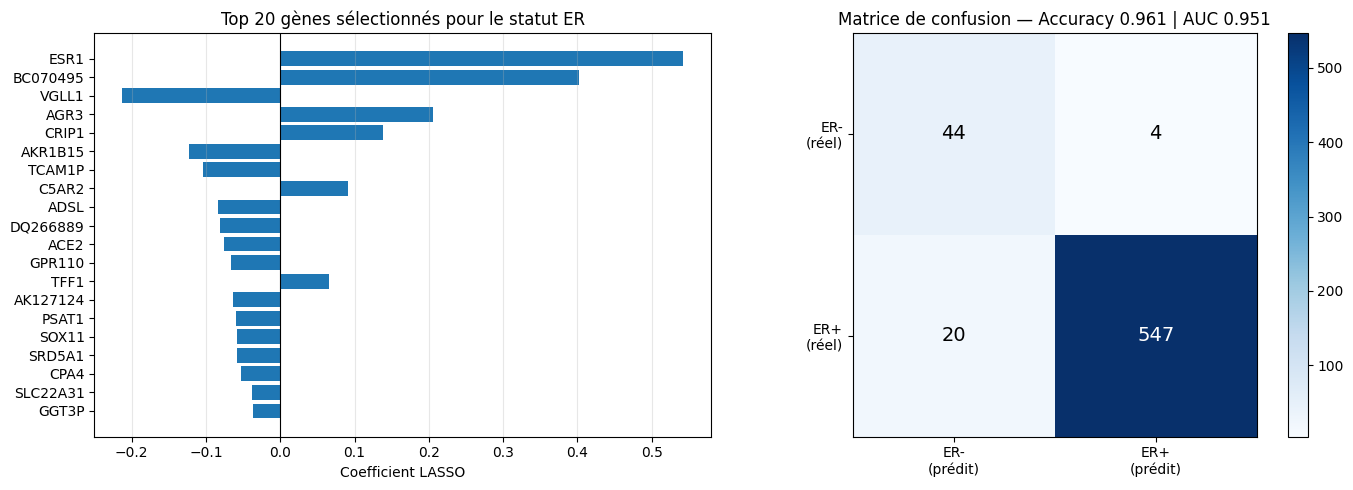

In [24]:
active_gene_names = np.array(gene_names)[active_mask_geo]
active_coefs_geo = coef_geo[active_mask_geo]

sorted_idx = np.argsort(np.abs(active_coefs_geo))[::-1]
top_k = min(20, len(sorted_idx))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    active_gene_names[sorted_idx[:top_k]][::-1],
    active_coefs_geo[sorted_idx[:top_k]][::-1]
)

axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Coefficient LASSO")
axes[0].set_title(f"Top {top_k} gènes sélectionnés pour le statut ER")
axes[0].grid(axis="x", alpha=0.3)

im = axes[1].imshow(cm_geo, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["ER-\n(prédit)", "ER+\n(prédit)"])
axes[1].set_yticklabels(["ER-\n(réel)", "ER+\n(réel)"])

for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, str(cm_geo[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm_geo[i, j] > cm_geo.max() / 2 else "black"
        )

axes[1].set_title(f"Matrice de confusion — Accuracy {acc_geo:.3f} | AUC {auc_geo:.3f}")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

### Interprétation

Les résultats montrent que le LASSO logistique reste applicable dans un cadre beaucoup plus difficile que celui du jeu de données Wisconsin. Ici, le nombre de variables initiales est très élevé, car chaque échantillon est décrit par plusieurs dizaines de milliers de gènes. Après une présélection statistique réalisée uniquement sur l'ensemble d'entraînement, le modèle est appris sur 3000 gènes, ce qui reste un cadre haute dimension.

Le modèle obtient une bonne performance sur l'ensemble de test, avec une accuracy d'environ 0.956 et une AUC d'environ 0.960. La matrice de confusion montre que la majorité des tumeurs ER+ et ER− sont correctement classées. L'utilisation de `class_weight="balanced"` est importante, car les classes sont déséquilibrées : les échantillons ER+ sont beaucoup plus nombreux que les échantillons ER−.

Le LASSO sélectionne seulement une partie des gènes parmi les 3000 variables gardées après présélection. Cela illustre bien l'intérêt de la pénalisation L1 : elle permet de construire un modèle prédictif tout en réduisant fortement le nombre de variables actives. Cependant, l'interprétation biologique des gènes sélectionnés doit rester prudente. La présélection, la corrélation entre gènes et le déséquilibre des classes peuvent influencer la liste finale. Une validation biologique ou une analyse de stabilité plus complète serait nécessaire pour conclure sur le rôle réel de ces gènes.